In [ ]:
import os
print(os.listdir('raw_data'))

In [1]:
import os
print("Current working directory:", os.getcwd())
print(os.listdir('raw_data'))

Current working directory: c:\Users\user\Desktop\auth_anomaly_detection_LANL
['auth.txt.gz', 'redteam.txt.gz']


In [2]:
import gzip

times = []
with gzip.open('raw_data/redteam.txt.gz', 'rt') as f:
    for line in f:
        times.append(int(line.split(',', 1)[0]))

print(f"Total red team events: {len(times):,}")
print(f"Earliest timestamp: {min(times):,}")
print(f"Latest timestamp:   {max(times):,}")
print(f"Span: {(max(times) - min(times)) / 86400:.2f} days")
print(f"\nFirst attack occurs at day {min(times) / 86400:.2f} of the dataset")
print(f"Last attack occurs at day {max(times) / 86400:.2f} of the dataset")

Total red team events: 749
Earliest timestamp: 150,885
Latest timestamp:   2,557,047
Span: 27.85 days

First attack occurs at day 1.75 of the dataset
Last attack occurs at day 29.60 of the dataset


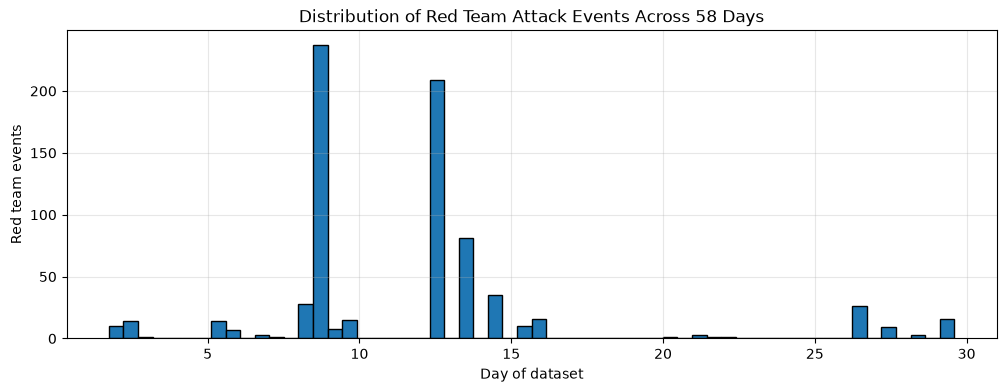

Top 10 densest days for red team activity:
  Day 8: 273 attack events
  Day 12: 209 attack events
  Day 13: 81 attack events
  Day 14: 35 attack events
  Day 26: 26 attack events
  Day 15: 26 attack events
  Day 5: 21 attack events
  Day 29: 16 attack events
  Day 9: 15 attack events
  Day 2: 15 attack events

Best 3-day rolling window (highest combined attack count):
  Days 12 to 15: 325 attack events


In [3]:
import matplotlib.pyplot as plt
import numpy as np

times_days = np.array(times) / 86400

plt.figure(figsize=(12, 4))
plt.hist(times_days, bins=58, edgecolor='black')
plt.xlabel('Day of dataset')
plt.ylabel('Red team events')
plt.title('Distribution of Red Team Attack Events Across 58 Days')
plt.grid(alpha=0.3)
plt.show()

# Find the single densest day for a tight, defensible slice
day_bins = np.floor(times_days).astype(int)
unique_days, counts = np.unique(day_bins, return_counts=True)

# Show top 10 densest days
sorted_idx = np.argsort(-counts)
print("Top 10 densest days for red team activity:")
for idx in sorted_idx[:10]:
    print(f"  Day {unique_days[idx]}: {counts[idx]} attack events")

# Find the best 3-day rolling window
print("\nBest 3-day rolling window (highest combined attack count):")
best_window_start = None
best_window_count = 0
for start_day in unique_days:
    window_count = sum(counts[(unique_days >= start_day) & (unique_days < start_day + 3)])
    if window_count > best_window_count:
        best_window_count = window_count
        best_window_start = start_day

print(f"  Days {best_window_start} to {best_window_start + 3}: {best_window_count} attack events")

In [4]:
import gzip
import time as time_module

# Days 12 to 15 → convert to seconds
SLICE_START = 12 * 86400   # 1,036,800
SLICE_END   = 15 * 86400   # 1,296,000

print(f"Extracting auth.txt.gz events from second {SLICE_START:,} to {SLICE_END:,}")
print(f"(Days 12 to 15 — our densest attack window)")
print("This will take a few minutes since auth.txt.gz is 7.2GB compressed...\n")

start_time = time_module.time()
lines_written = 0
lines_scanned = 0

with gzip.open('raw_data/auth.txt.gz', 'rt') as f_in, open('raw_data/auth_slice.txt', 'w') as f_out:
    for line in f_in:
        lines_scanned += 1

        # Print progress every 5 million lines scanned
        if lines_scanned % 5_000_000 == 0:
            elapsed = time_module.time() - start_time
            print(f"  Scanned {lines_scanned:,} lines... ({elapsed:.0f}s elapsed)")

        time_val = int(line.split(',', 1)[0])

        if time_val < SLICE_START:
            continue   # haven't reached our window yet, keep scanning
        if time_val > SLICE_END:
            break      # past our window, file is time-ordered so we can stop

        f_out.write(line)
        lines_written += 1

elapsed = time_module.time() - start_time
print(f"\nDone in {elapsed:.0f} seconds")
print(f"Total lines scanned: {lines_scanned:,}")
print(f"Lines written to slice: {lines_written:,}")

Extracting auth.txt.gz events from second 1,036,800 to 1,296,000
(Days 12 to 15 — our densest attack window)
This will take a few minutes since auth.txt.gz is 7.2GB compressed...

  Scanned 5,000,000 lines... (5s elapsed)
  Scanned 10,000,000 lines... (10s elapsed)
  Scanned 15,000,000 lines... (15s elapsed)
  Scanned 20,000,000 lines... (20s elapsed)
  Scanned 25,000,000 lines... (26s elapsed)
  Scanned 30,000,000 lines... (31s elapsed)
  Scanned 35,000,000 lines... (37s elapsed)
  Scanned 40,000,000 lines... (43s elapsed)
  Scanned 45,000,000 lines... (49s elapsed)
  Scanned 50,000,000 lines... (55s elapsed)
  Scanned 55,000,000 lines... (62s elapsed)
  Scanned 60,000,000 lines... (68s elapsed)
  Scanned 65,000,000 lines... (74s elapsed)
  Scanned 70,000,000 lines... (80s elapsed)
  Scanned 75,000,000 lines... (86s elapsed)
  Scanned 80,000,000 lines... (92s elapsed)
  Scanned 85,000,000 lines... (97s elapsed)
  Scanned 90,000,000 lines... (103s elapsed)
  Scanned 95,000,000 lines...

In [5]:
import os
size_bytes = os.path.getsize('raw_data/auth_slice.txt')
print(f"auth_slice.txt size: {size_bytes / (1024**3):.2f} GB")

auth_slice.txt size: 3.97 GB


In [6]:
import gzip

attack_users = set()
attack_computers = set()

with gzip.open('raw_data/redteam.txt.gz', 'rt') as f:
    for line in f:
        parts = line.strip().split(',')
        t = int(parts[0])
        if 12*86400 <= t <= 15*86400:
            user, src_comp, dst_comp = parts[1], parts[2], parts[3]
            attack_users.add(user)
            attack_computers.add(src_comp)
            attack_computers.add(dst_comp)

print(f"Distinct attack users in this window: {len(attack_users)}")
print(f"Distinct attack computers in this window: {len(attack_computers)}")
print(f"\nSample attack users: {list(attack_users)[:10]}")
print(f"\nSample attack computers: {list(attack_computers)[:10]}")

Distinct attack users in this window: 61
Distinct attack computers in this window: 129

Sample attack users: ['U24@DOM1', 'U218@DOM1', 'U1789@DOM1', 'U66@DOM1', 'U78@DOM1', 'U1723@DOM1', 'U8777@DOM1', 'U2575@DOM1', 'U7507@DOM1', 'U737@C10']

Sample attack computers: ['C1581', 'C92', 'C1710', 'C828', 'C1936', 'C10', 'C22275', 'C307', 'C4773', 'C2519']


In [7]:
import gzip
import time as time_module

with gzip.open('raw_data/redteam.txt.gz', 'rt') as f:
    attack_computers = set()
    for line in f:
        parts = line.strip().split(',')
        t = int(parts[0])
        if 12*86400 <= t <= 15*86400:
            attack_computers.add(parts[2])  # source_computer
            attack_computers.add(parts[3])  # destination_computer

print(f"Filtering auth_slice.txt for {len(attack_computers)} attack-relevant computers...")
print("This reads from the already-extracted auth_slice.txt (fast, no need to rescan the full 7.2GB)\n")

start_time = time_module.time()
lines_scanned = 0
lines_written = 0

with open('raw_data/auth_slice.txt', 'r') as f_in, open('raw_data/auth_final.csv', 'w') as f_out:
    # Write header matching LANL's documented schema
    f_out.write("time,source_user,destination_user,source_computer,destination_computer,"
                 "authentication_type,logon_type,authentication_orientation,success_failure\n")

    for line in f_in:
        lines_scanned += 1
        if lines_scanned % 5_000_000 == 0:
            elapsed = time_module.time() - start_time
            print(f"  Scanned {lines_scanned:,} lines... ({elapsed:.0f}s elapsed, {lines_written:,} matched)")

        parts = line.strip().split(',')
        src_comp, dst_comp = parts[3], parts[4]

        if src_comp in attack_computers or dst_comp in attack_computers:
            f_out.write(line)
            lines_written += 1

elapsed = time_module.time() - start_time
print(f"\nDone in {elapsed:.0f} seconds")
print(f"Total lines scanned: {lines_scanned:,}")
print(f"Lines written to auth_final.csv: {lines_written:,}")

Filtering auth_slice.txt for 129 attack-relevant computers...
This reads from the already-extracted auth_slice.txt (fast, no need to rescan the full 7.2GB)

  Scanned 5,000,000 lines... (11s elapsed, 2,834,363 matched)
  Scanned 10,000,000 lines... (21s elapsed, 5,434,323 matched)
  Scanned 15,000,000 lines... (34s elapsed, 8,131,772 matched)
  Scanned 20,000,000 lines... (46s elapsed, 10,970,727 matched)
  Scanned 25,000,000 lines... (58s elapsed, 13,805,648 matched)
  Scanned 30,000,000 lines... (70s elapsed, 16,422,524 matched)
  Scanned 35,000,000 lines... (82s elapsed, 19,029,140 matched)
  Scanned 40,000,000 lines... (93s elapsed, 21,808,958 matched)
  Scanned 45,000,000 lines... (106s elapsed, 24,621,671 matched)
  Scanned 50,000,000 lines... (117s elapsed, 27,317,991 matched)
  Scanned 55,000,000 lines... (130s elapsed, 29,966,785 matched)
  Scanned 60,000,000 lines... (142s elapsed, 32,708,518 matched)

Done in 143 seconds
Total lines scanned: 60,783,704
Lines written to auth_

In [8]:
import pandas as pd

# Read just a sample to check computer frequency without loading everything
sample = pd.read_csv('raw_data/auth_final.csv', nrows=2_000_000)

print("Top 20 most frequent source_computer values:")
print(sample['source_computer'].value_counts().head(20))
print()
print("Top 20 most frequent destination_computer values:")
print(sample['destination_computer'].value_counts().head(20))

Top 20 most frequent source_computer values:
source_computer
C586     224888
C625     134886
C529     132348
C528     130613
C457     123299
C467     117703
C1015     23509
C1085     22595
C3173     20136
C553      17862
C585      13234
C743      13000
C1115      9409
C5618      8743
C506       8342
C480       8095
C1710      7570
C10        7252
C368       7224
C477       6130
Name: count, dtype: int64

Top 20 most frequent destination_computer values:
destination_computer
C586     490471
C625     265490
C529     260907
C528     258311
C457     249075
C467     232445
C1015     45900
C1085     37659
C3173     36562
C553      28191
C5618     17441
C10       14544
C612      10209
C1710      7475
C368       7005
U22        5554
C1581      3710
C1065      3704
C92        2856
C231       2348
Name: count, dtype: int64


In [9]:
import gzip

attack_users = set()
with gzip.open('raw_data/redteam.txt.gz', 'rt') as f:
    for line in f:
        parts = line.strip().split(',')
        t = int(parts[0])
        if 12*86400 <= t <= 15*86400:
            attack_users.add(parts[1])

print(f"Attack users to filter on: {len(attack_users)}")

Attack users to filter on: 61


In [10]:
import time as time_module

print(f"Filtering auth_slice.txt for {len(attack_users)} attack-relevant users...")
print("Reading from auth_slice.txt (Days 12-15 slice)\n")

start_time = time_module.time()
lines_scanned = 0
lines_written = 0

with open('raw_data/auth_slice.txt', 'r') as f_in, open('raw_data/auth_final.csv', 'w') as f_out:
    f_out.write("time,source_user,destination_user,source_computer,destination_computer,"
                 "authentication_type,logon_type,authentication_orientation,success_failure\n")

    for line in f_in:
        lines_scanned += 1
        if lines_scanned % 10_000_000 == 0:
            elapsed = time_module.time() - start_time
            print(f"  Scanned {lines_scanned:,} lines... ({elapsed:.0f}s elapsed, {lines_written:,} matched)")

        parts = line.strip().split(',')
        src_user, dst_user = parts[1], parts[2]

        if src_user in attack_users or dst_user in attack_users:
            f_out.write(line)
            lines_written += 1

elapsed = time_module.time() - start_time
print(f"\nDone in {elapsed:.0f} seconds")
print(f"Total lines scanned: {lines_scanned:,}")
print(f"Lines written to auth_final.csv: {lines_written:,}")

Filtering auth_slice.txt for 61 attack-relevant users...
Reading from auth_slice.txt (Days 12-15 slice)

  Scanned 10,000,000 lines... (15s elapsed, 166,664 matched)
  Scanned 20,000,000 lines... (30s elapsed, 330,733 matched)
  Scanned 30,000,000 lines... (46s elapsed, 484,774 matched)
  Scanned 40,000,000 lines... (61s elapsed, 645,188 matched)
  Scanned 50,000,000 lines... (77s elapsed, 797,951 matched)
  Scanned 60,000,000 lines... (92s elapsed, 960,805 matched)

Done in 93 seconds
Total lines scanned: 60,783,704
Lines written to auth_final.csv: 973,883


In [11]:
import pandas as pd

df_check = pd.read_csv('raw_data/auth_final.csv', nrows=2_000_000)

print(f"Total rows in sample: {len(df_check):,}")
print()
print("How many matched via source_user only:")
print((df_check['source_user'].isin(attack_users)).sum())
print()
print("How many matched via destination_user only:")
print((df_check['destination_user'].isin(attack_users)).sum())
print()
print("Top 10 most frequent destination_user values among matches:")
print(df_check['destination_user'].value_counts().head(10))

Total rows in sample: 973,883

How many matched via source_user only:
966451

How many matched via destination_user only:
953495

Top 10 most frequent destination_user values among matches:
destination_user
U66@DOM1      538452
U13@DOM1       65581
U78@DOM1       60911
U24@DOM1       50713
U1653@DOM1     30361
U12@DOM1       23475
U5254@DOM1     18967
U453@DOM1      13069
U1450@DOM1     11356
U342@DOM1       9079
Name: count, dtype: int64


In [12]:
import time as time_module

print(f"Filtering auth_slice.txt — source_user matches attack users ONLY")
print("(dropping destination_user matching to eliminate hub-account flooding)\n")

start_time = time_module.time()
lines_scanned = 0
lines_written = 0

with open('raw_data/auth_slice.txt', 'r') as f_in, open('raw_data/auth_final.csv', 'w') as f_out:
    f_out.write("time,source_user,destination_user,source_computer,destination_computer,"
                 "authentication_type,logon_type,authentication_orientation,success_failure\n")

    for line in f_in:
        lines_scanned += 1
        if lines_scanned % 10_000_000 == 0:
            elapsed = time_module.time() - start_time
            print(f"  Scanned {lines_scanned:,} lines... ({elapsed:.0f}s elapsed, {lines_written:,} matched)")

        parts = line.strip().split(',')
        src_user = parts[1]

        if src_user in attack_users:
            f_out.write(line)
            lines_written += 1

elapsed = time_module.time() - start_time
print(f"\nDone in {elapsed:.0f} seconds")
print(f"Total lines scanned: {lines_scanned:,}")
print(f"Lines written to auth_final.csv: {lines_written:,}")

Filtering auth_slice.txt — source_user matches attack users ONLY
(dropping destination_user matching to eliminate hub-account flooding)

  Scanned 10,000,000 lines... (13s elapsed, 165,171 matched)
  Scanned 20,000,000 lines... (25s elapsed, 328,134 matched)
  Scanned 30,000,000 lines... (39s elapsed, 480,758 matched)
  Scanned 40,000,000 lines... (53s elapsed, 639,991 matched)
  Scanned 50,000,000 lines... (67s elapsed, 791,581 matched)
  Scanned 60,000,000 lines... (81s elapsed, 953,426 matched)

Done in 82 seconds
Total lines scanned: 60,783,704
Lines written to auth_final.csv: 966,451


In [13]:
import pandas as pd

df_check = pd.read_csv('raw_data/auth_final.csv')
print(f"Total rows: {len(df_check):,}")
print()
print("Top 15 source_user values by frequency:")
print(df_check['source_user'].value_counts().head(15))
print()
print(f"Number of distinct source_users actually present: {df_check['source_user'].nunique()}")
print(f"(out of {len(attack_users)} attack users we filtered for)")

Total rows: 966,451

Top 15 source_user values by frequency:
source_user
U66@DOM1      538399
U13@DOM1       69337
U78@DOM1       65110
U24@DOM1       53429
U1653@DOM1     33095
U12@DOM1       23491
U5254@DOM1     18943
U453@DOM1      12861
U1450@DOM1     11317
U86@DOM1        9467
U342@DOM1       9077
U3486@DOM1      7850
U1592@DOM1      7557
U20@DOM1        6120
U3635@DOM1      5685
Name: count, dtype: int64

Number of distinct source_users actually present: 61
(out of 61 attack users we filtered for)


In [14]:
# Check if U66's events are concentrated attack-period bursts,
# or spread evenly (suggesting it's a generic/shared account)
u66_events = df_check[df_check['source_user'] == 'U66@DOM1']

print(f"U66 total events: {len(u66_events):,}")
print(f"\nTime range of U66 activity:")
print(f"  Earliest: {u66_events['time'].min():,}")
print(f"  Latest:   {u66_events['time'].max():,}")
print()
print("Destination computers U66 authenticated to (top 10):")
print(u66_events['destination_computer'].value_counts().head(10))
print()
print("success_failure breakdown for U66:")
print(u66_events['success_failure'].value_counts())

U66 total events: 538,399

Time range of U66 activity:
  Earliest: 1,036,801
  Latest:   1,296,000

Destination computers U66 authenticated to (top 10):
destination_computer
C1952    19706
C1697    18540
C1732    16499
C1971    14447
C2084    11492
C779     11215
C1870    11168
C2127    10760
C1747     9775
C72       9736
Name: count, dtype: int64

success_failure breakdown for U66:
success_failure
Success    538373
Fail           26
Name: count, dtype: int64


In [15]:
# Remove the dominant noise account
attack_users_clean = attack_users - {'U66@DOM1'}
print(f"Attack users after removing U66: {len(attack_users_clean)}")

# Re-filter from the already-extracted auth_final.csv (fast, in-memory)
df_clean = df_check[df_check['source_user'].isin(attack_users_clean)].copy()

print(f"\nTotal rows after removing U66: {len(df_clean):,}")
print(f"\nTop 15 source_user values by frequency (after exclusion):")
print(df_clean['source_user'].value_counts().head(15))

Attack users after removing U66: 60

Total rows after removing U66: 428,052

Top 15 source_user values by frequency (after exclusion):
source_user
U13@DOM1      69337
U78@DOM1      65110
U24@DOM1      53429
U1653@DOM1    33095
U12@DOM1      23491
U5254@DOM1    18943
U453@DOM1     12861
U1450@DOM1    11317
U86@DOM1       9467
U342@DOM1      9077
U3486@DOM1     7850
U1592@DOM1     7557
U20@DOM1       6120
U3635@DOM1     5685
U1506@DOM1     5409
Name: count, dtype: int64


In [16]:
for user in ['U13@DOM1', 'U78@DOM1', 'U24@DOM1']:
    u_events = df_clean[df_clean['source_user'] == user]
    print(f"=== {user} ===")
    print(f"Total events: {len(u_events):,}")
    print(f"Time range: {u_events['time'].min():,} to {u_events['time'].max():,}")
    print(f"Success/Fail breakdown:")
    print(u_events['success_failure'].value_counts())
    print(f"Distinct destination computers: {u_events['destination_computer'].nunique()}")
    print()

=== U13@DOM1 ===
Total events: 69,337
Time range: 1,036,801 to 1,295,996
Success/Fail breakdown:
success_failure
Success    69337
Name: count, dtype: int64
Distinct destination computers: 30

=== U78@DOM1 ===
Total events: 65,110
Time range: 1,036,801 to 1,296,000
Success/Fail breakdown:
success_failure
Success    65110
Name: count, dtype: int64
Distinct destination computers: 57

=== U24@DOM1 ===
Total events: 53,429
Time range: 1,036,801 to 1,295,918
Success/Fail breakdown:
success_failure
Success    53421
Fail           8
Name: count, dtype: int64
Distinct destination computers: 55



In [17]:
import numpy as np

user_counts = df_clean['source_user'].value_counts()

print("Distribution of event counts across the 60 attack users:")
print(user_counts.describe())
print()
print("Percentiles:")
for p in [50, 75, 90, 95, 99]:
    print(f"  {p}th percentile: {np.percentile(user_counts.values, p):.0f} events")
print()
print("Full sorted list (all 60 users):")
print(user_counts.to_string())

Distribution of event counts across the 60 attack users:
count       60.000000
mean      7134.200000
std      14168.009436
min          2.000000
25%        920.250000
50%       3225.000000
75%       5274.000000
max      69337.000000
Name: count, dtype: float64

Percentiles:
  50th percentile: 3225 events
  75th percentile: 5274 events
  90th percentile: 13469 events
  95th percentile: 34112 events
  99th percentile: 66843 events

Full sorted list (all 60 users):
source_user
U13@DOM1        69337
U78@DOM1        65110
U24@DOM1        53429
U1653@DOM1      33095
U12@DOM1        23491
U5254@DOM1      18943
U453@DOM1       12861
U1450@DOM1      11317
U86@DOM1         9467
U342@DOM1        9077
U3486@DOM1       7850
U1592@DOM1       7557
U20@DOM1         6120
U3635@DOM1       5685
U1506@DOM1       5409
U9263@DOM1       5229
U9407@DOM1       5015
U2575@DOM1       4795
U1723@DOM1       4791
U1480@DOM1       4449
U207@DOM1        4306
U8777@DOM1       3930
U162@DOM1        3902
U114@DOM1      

In [18]:
import pandas as pd

MAX_EVENTS_PER_USER = 200  # caps even the busiest account at a manageable level

df_capped = (
    df_clean.groupby('source_user', group_keys=False)
    .apply(lambda x: x.sample(n=min(len(x), MAX_EVENTS_PER_USER), random_state=42))
)

print(f"Total rows after capping at {MAX_EVENTS_PER_USER} per user: {len(df_capped):,}")
print(f"\nNew distribution check:")
print(df_capped['source_user'].value_counts().describe())
print(f"\nSuccess/Fail breakdown across capped dataset:")
print(df_capped['success_failure'].value_counts())

Total rows after capping at 200 per user: 10,221

New distribution check:


KeyError: 'source_user'

In [19]:
import pandas as pd

MAX_EVENTS_PER_USER = 200

# Build the capped sample manually, group by group, to avoid the
# pandas 3.x groupby().apply() column-dropping issue
capped_parts = []
for user, group in df_clean.groupby('source_user'):
    n = min(len(group), MAX_EVENTS_PER_USER)
    capped_parts.append(group.sample(n=n, random_state=42))

df_capped = pd.concat(capped_parts, ignore_index=True)

print(f"Total rows after capping at {MAX_EVENTS_PER_USER} per user: {len(df_capped):,}")
print(f"\nColumns present: {df_capped.columns.tolist()}")
print(f"\nNew distribution check:")
print(df_capped['source_user'].value_counts().describe())
print(f"\nSuccess/Fail breakdown across capped dataset:")
print(df_capped['success_failure'].value_counts())

Total rows after capping at 200 per user: 10,221

Columns present: ['time', 'source_user', 'destination_user', 'source_computer', 'destination_computer', 'authentication_type', 'logon_type', 'authentication_orientation', 'success_failure']

New distribution check:
count     60.000000
mean     170.350000
std       69.367316
min        2.000000
25%      200.000000
50%      200.000000
75%      200.000000
max      200.000000
Name: count, dtype: float64

Success/Fail breakdown across capped dataset:
success_failure
Success    10200
Fail          21
Name: count, dtype: int64


In [20]:
import gzip

# Get the full list of attack users (all 749 across the whole 58 days,
# not just our 3-day window) so we correctly EXCLUDE them from "normal"
all_attack_users = set()
with gzip.open('raw_data/redteam.txt.gz', 'rt') as f:
    for line in f:
        parts = line.strip().split(',')
        all_attack_users.add(parts[1])

print(f"Total distinct attack users across entire 58-day dataset: {len(all_attack_users)}")

Total distinct attack users across entire 58-day dataset: 104


In [21]:
import time as time_module
import random

random.seed(42)

TARGET_NORMAL_SAMPLE = 6000   # roughly matches your OTRF dataset's normal-event scale
SAMPLE_PROBABILITY = 0.002    # reservoir-style probabilistic sampling to avoid loading everything

print("Scanning auth_slice.txt for normal (non-attack) user events...")
print(f"Using probabilistic sampling (~{SAMPLE_PROBABILITY*100}% of eligible rows)\n")

start_time = time_module.time()
lines_scanned = 0
normal_rows = []

with open('raw_data/auth_slice.txt', 'r') as f_in:
    for line in f_in:
        lines_scanned += 1
        if lines_scanned % 10_000_000 == 0:
            elapsed = time_module.time() - start_time
            print(f"  Scanned {lines_scanned:,} lines... ({elapsed:.0f}s elapsed, {len(normal_rows):,} collected)")

        parts = line.strip().split(',')
        src_user = parts[1]

        if src_user in all_attack_users:
            continue  # skip any compromised account, even if active outside our window

        if random.random() < SAMPLE_PROBABILITY:
            normal_rows.append(line.strip())

        if len(normal_rows) >= TARGET_NORMAL_SAMPLE * 3:  # collect extra, trim later
            break

elapsed = time_module.time() - start_time
print(f"\nDone in {elapsed:.0f} seconds")
print(f"Total lines scanned: {lines_scanned:,}")
print(f"Normal rows collected: {len(normal_rows):,}")

Scanning auth_slice.txt for normal (non-attack) user events...
Using probabilistic sampling (~0.2% of eligible rows)


Done in 13 seconds
Total lines scanned: 9,324,892
Normal rows collected: 18,000


In [22]:
import pandas as pd
import random

random.seed(42)

# Trim normal rows down to our target size
normal_sample = random.sample(normal_rows, TARGET_NORMAL_SAMPLE)

# Parse into a DataFrame with the same column structure as df_capped
columns = ['time', 'source_user', 'destination_user', 'source_computer',
           'destination_computer', 'authentication_type', 'logon_type',
           'authentication_orientation', 'success_failure']

normal_data = [row.split(',') for row in normal_sample]
df_normal = pd.DataFrame(normal_data, columns=columns)
df_normal['time'] = df_normal['time'].astype(int)

print(f"Normal events: {len(df_normal):,}")
print(f"Attack events: {len(df_capped):,}")

# Add ground truth labels before combining
df_capped['is_attack'] = 1
df_normal['is_attack'] = 0

# Combine into final dataset
df_final = pd.concat([df_capped, df_normal], ignore_index=True)
df_final = df_final.sort_values('time').reset_index(drop=True)

print(f"\nFinal combined dataset: {len(df_final):,} events")
print(f"Attack ratio: {df_final['is_attack'].mean()*100:.2f}%")
print(f"\nClass balance:")
print(df_final['is_attack'].value_counts())
print(f"\nColumn check:")
print(df_final.columns.tolist())
print(f"\nSample rows:")
print(df_final.head(10))

Normal events: 6,000
Attack events: 10,221

Final combined dataset: 16,221 events
Attack ratio: 63.01%

Class balance:
is_attack
1    10221
0     6000
Name: count, dtype: int64

Column check:
['time', 'source_user', 'destination_user', 'source_computer', 'destination_computer', 'authentication_type', 'logon_type', 'authentication_orientation', 'success_failure', 'is_attack']

Sample rows:
      time  source_user destination_user source_computer destination_computer  \
0  1036801  C3745$@DOM1     SYSTEM@C3745           C3745                C3745   
1  1036803     U86@DOM1         U86@DOM1            C561                 C561   
2  1036807    U158@DOM1        U158@DOM1           C1705                C1691   
3  1036812   C227$@DOM1       C227$@DOM1            C227                 C586   
4  1036832   C599$@DOM1       C599$@DOM1           C1619                C1085   
5  1036833   C994$@DOM1       C994$@DOM1            C994                C1015   
6  1036836  C2390$@DOM1      C2390$@DOM1 

In [23]:
import random

random.seed(42)

# Target a more realistic ~12-15% attack ratio, matching your OTRF framing
TARGET_ATTACK_RATIO = 0.15
target_normal_count = int(len(df_capped) / TARGET_ATTACK_RATIO - len(df_capped))

print(f"Attack events (fixed): {len(df_capped):,}")
print(f"Target normal events for ~{TARGET_ATTACK_RATIO*100:.0f}% attack ratio: {target_normal_count:,}")

# We already have 18,000 normal rows collected — check if that's enough
print(f"\nNormal rows available in buffer: {len(normal_rows):,}")

Attack events (fixed): 10,221
Target normal events for ~15% attack ratio: 57,919

Normal rows available in buffer: 18,000


In [24]:
import time as time_module
import random

random.seed(42)

TARGET_NORMAL_SAMPLE = 58000
SAMPLE_PROBABILITY = 0.01   # increased sampling rate to gather more, faster

print("Re-scanning auth_slice.txt for a larger normal sample...")
print(f"Target: {TARGET_NORMAL_SAMPLE:,} normal events\n")

start_time = time_module.time()
lines_scanned = 0
normal_rows = []

with open('raw_data/auth_slice.txt', 'r') as f_in:
    for line in f_in:
        lines_scanned += 1
        if lines_scanned % 10_000_000 == 0:
            elapsed = time_module.time() - start_time
            print(f"  Scanned {lines_scanned:,} lines... ({elapsed:.0f}s elapsed, {len(normal_rows):,} collected)")

        parts = line.strip().split(',')
        src_user = parts[1]

        if src_user in all_attack_users:
            continue

        if random.random() < SAMPLE_PROBABILITY:
            normal_rows.append(line.strip())

        if len(normal_rows) >= TARGET_NORMAL_SAMPLE:
            break

elapsed = time_module.time() - start_time
print(f"\nDone in {elapsed:.0f} seconds")
print(f"Total lines scanned: {lines_scanned:,}")
print(f"Normal rows collected: {len(normal_rows):,}")

Re-scanning auth_slice.txt for a larger normal sample...
Target: 58,000 normal events


Done in 8 seconds
Total lines scanned: 5,947,006
Normal rows collected: 58,000


In [25]:
import pandas as pd
import random

random.seed(42)

columns = ['time', 'source_user', 'destination_user', 'source_computer',
           'destination_computer', 'authentication_type', 'logon_type',
           'authentication_orientation', 'success_failure']

normal_data = [row.split(',') for row in normal_rows]
df_normal = pd.DataFrame(normal_data, columns=columns)
df_normal['time'] = df_normal['time'].astype(int)

print(f"Normal events: {len(df_normal):,}")
print(f"Attack events: {len(df_capped):,}")

# Add ground truth labels
df_capped['is_attack'] = 1
df_normal['is_attack'] = 0

# Combine and sort chronologically
df_final = pd.concat([df_capped, df_normal], ignore_index=True)
df_final = df_final.sort_values('time').reset_index(drop=True)

print(f"\nFinal combined dataset: {len(df_final):,} events")
print(f"Attack ratio: {df_final['is_attack'].mean()*100:.2f}%")
print(f"\nClass balance:")
print(df_final['is_attack'].value_counts())

Normal events: 58,000
Attack events: 10,221

Final combined dataset: 68,221 events
Attack ratio: 14.98%

Class balance:
is_attack
0    58000
1    10221
Name: count, dtype: int64


In [26]:
df_final.to_csv('parsed_logs.csv', index=False)

print(f"Saved parsed_logs.csv")
print(f"Total events: {len(df_final):,}")
print(f"Attack events: {df_final['is_attack'].sum():,} ({df_final['is_attack'].mean()*100:.2f}%)")
print(f"Normal events: {(df_final['is_attack']==0).sum():,}")
print(f"\nFile size check:")

import os
size_mb = os.path.getsize('parsed_logs.csv') / (1024**2)
print(f"  parsed_logs.csv: {size_mb:.2f} MB")

print(f"\nColumn summary:")
print(df_final.dtypes)

print(f"\nFinal sanity check — first 5 rows:")
print(df_final.head())

Saved parsed_logs.csv
Total events: 68,221
Attack events: 10,221 (14.98%)
Normal events: 58,000

File size check:
  parsed_logs.csv: 4.65 MB

Column summary:
time                          int64
source_user                     str
destination_user                str
source_computer                 str
destination_computer            str
authentication_type             str
logon_type                      str
authentication_orientation      str
success_failure                 str
is_attack                     int64
dtype: object

Final sanity check — first 5 rows:
      time   source_user destination_user source_computer  \
0  1036800  C11731$@DOM1     C11731$@DOM1          C11731   
1  1036800   C5396$@DOM1      C5396$@DOM1            C457   
2  1036801  C14431$@DOM1     C14431$@DOM1           C1065   
3  1036801   C1484$@DOM1        U198@DOM1           C1484   
4  1036801     U198@DOM1        U198@DOM1           C1484   

  destination_computer authentication_type logon_type  \
0       

In [27]:
attack_subset = df_final[df_final['is_attack'] == 1]
normal_subset = df_final[df_final['is_attack'] == 0]

print("authentication_type — overlap check:")
attack_auth_types = set(attack_subset['authentication_type'].unique())
normal_auth_types = set(normal_subset['authentication_type'].unique())
print(f"  In both: {attack_auth_types & normal_auth_types}")
print(f"  Attack only: {attack_auth_types - normal_auth_types}")
print(f"  Normal only: {normal_auth_types - attack_auth_types}")

print("\nlogon_type — overlap check:")
attack_logon_types = set(attack_subset['logon_type'].unique())
normal_logon_types = set(normal_subset['logon_type'].unique())
print(f"  In both: {attack_logon_types & normal_logon_types}")
print(f"  Attack only: {attack_logon_types - normal_logon_types}")
print(f"  Normal only: {normal_logon_types - attack_logon_types}")

authentication_type — overlap check:
  In both: {'NTLM', 'Negotiate', 'Kerberos', '?'}
  Attack only: set()
  Normal only: {'MICROSOFT_AUTHENTICATION_PACKAGE_V1', 'MICROSOFT_AUTHENTICATION_PACKAGE', 'MICROSOFT_AUTHENTICATION_PACKAGE_V1_0', 'MICROSOFT_AUTHENTICATION_PACKAG'}

logon_type — overlap check:
  In both: {'Service', 'Network', '?', 'Unlock', 'RemoteInteractive', 'Batch', 'CachedInteractive', 'Interactive'}
  Attack only: set()
  Normal only: {'NetworkCleartext', 'NewCredentials'}
